# 09 — 模型可视化验证

加载训练好的 MS-SCNF 模型，与验证数据（2D图像 + 3D骨架）进行交互式对比。

**功能**:
- 真实2D相机图像 vs 模型体渲染2D图像
- 真实3D点云+骨架 vs 模型预测3D点云+骨架
- 叠加差异可视化（2D + 3D）
- 滑块选择帧、调节密度/可见度阈值
- 预测分布分析、逐节点误差、密度场切片

In [1]:
# ====== GPU 选择（必须在 import torch 之前）======
import os, sys, glob

GPU_ID = 1          # ← 修改这里选择 GPU（0, 1, 2, ...）
os.environ['CUDA_VISIBLE_DEVICES'] = str(GPU_ID)

PROJECT_ROOT = os.path.dirname(os.getcwd())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f'可用 GPU 数量: {n_gpus}')
if n_gpus > 0:
    for i in range(n_gpus):
        mem = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} ({mem:.1f} GB)')
    print(f'→ 已选择 GPU {GPU_ID}: {torch.cuda.get_device_name(0)}')
else:
    print('⚠ 未检测到 GPU，将使用 CPU')
print(f'Project root: {PROJECT_ROOT}')

import numpy as np
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider, FloatSlider

from src.utils.model_loader import load_model
from src.data.dataset import SoftSequenceDataset
from src.utils.skeleton_viz import BOUNDS, render_density_field, print_metrics
from src.utils.camera import get_rays
from src.utils.rendering import OM_rendering, sample_stratified

可用 GPU 数量: 1
  GPU 0: NVIDIA GeForce RTX 3090 (23.6 GB)
→ 已选择 GPU 1: NVIDIA GeForce RTX 3090
Project root: /Data5/ddf/projects/SelfSoftRobot


In [2]:
# ====== 在这里选择模型和数据 ======

# 自动扫描所有可用 checkpoint（使用 PROJECT_ROOT 确保路径正确）
ckpt_base = os.path.join(PROJECT_ROOT, 'train_log')
all_ckpts = sorted(glob.glob(os.path.join(ckpt_base, '**/best_model.pt'), recursive=True))
all_ckpts += sorted(glob.glob(os.path.join(ckpt_base, '**/skeleton_best.pt'), recursive=True))
all_ckpts += sorted(glob.glob(os.path.join(ckpt_base, '**/canonical_best.pt'), recursive=True))
output_base = os.path.join(PROJECT_ROOT, 'output')
all_ckpts += sorted(glob.glob(os.path.join(output_base, '**/*.pt'), recursive=True))
# 去重
all_ckpts = sorted(set(all_ckpts))

print(f'可用模型 ({len(all_ckpts)} 个):')
for i, p in enumerate(all_ckpts):
    print(f'  [{i}] {p}')

# 3D 数据目录
data_base = os.path.join(PROJECT_ROOT, 'data')
data_3d_dirs = sorted(glob.glob(os.path.join(data_base, 'seq_*_3d')))
data_3d_dirs += sorted(glob.glob(os.path.join(data_base, 'exp7_*')))
data_3d_dirs += sorted(glob.glob(os.path.join(data_base, 'multiview_*')))
data_3d_dirs = [d for d in sorted(set(data_3d_dirs)) if os.path.isdir(d)]
print(f'\n可用3D数据目录 ({len(data_3d_dirs)} 个):')
for i, d in enumerate(data_3d_dirs):
    n_files = len(glob.glob(os.path.join(d, '*.npz')))
    print(f'  [{i}] {d} ({n_files} files)')

if not all_ckpts:
    print('\n⚠ 未找到模型！请确认 train_log/ 目录下有训练好的 checkpoint。')
if not data_3d_dirs:
    print('\n⚠ 未找到3D数据！请确认 data/ 目录下有 seq_*_3d 文件夹。')

可用模型 (25 个):
  [0] /Data5/ddf/projects/SelfSoftRobot/output/exp1_skeleton_2d/model_2d_skeleton.pt
  [1] /Data5/ddf/projects/SelfSoftRobot/output/exp1b_improved_2d/model_improved_2d.pt
  [2] /Data5/ddf/projects/SelfSoftRobot/output/exp7_multiview_2d/model_phase1.pt
  [3] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_2/phase1/model/canonical_best.pt
  [4] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_2/phase2/model/best_model.pt
  [5] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_3/phase1/model/canonical_best.pt
  [6] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_3/phase2/model/best_model.pt
  [7] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_4/phase1/model/canonical_best.pt
  [8] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_4/phase2/model/best_model.pt
  [9] /Data5/ddf/projects/SelfSoftRobot/train_log/train_cmstnf/exp_20260425_5/phase1/model/ca

In [3]:
# ====== 设置选择（修改索引即可）======
assert all_ckpts, '没有找到模型 checkpoint，请先训练或检查路径。'
assert data_3d_dirs, '没有找到3D数据，请检查 data/ 目录。'

CHECKPOINT_IDX = min(11, len(all_ckpts) - 1)   # 从上面列表选择
DATA_IDX = min(2, len(data_3d_dirs) - 1)         # 从上面列表选择

checkpoint_path = all_ckpts[CHECKPOINT_IDX]
data_dir = data_3d_dirs[DATA_IDX]

print(f'模型: {checkpoint_path}')
print(f'数据: {data_dir}')

模型: /Data5/ddf/projects/SelfSoftRobot/train_log/train_ms_scnf/exp_20260427_0/phase2/model/best_model.pt
数据: /Data5/ddf/projects/SelfSoftRobot/data/seq_rz_3d


In [4]:
# 加载模型
info = load_model(checkpoint_path, data_dir=data_dir, device=device)
model = info['model']
model_type = info['model_type']
phase = info['phase']
is_ms_scnf = model_type == 'ms_scnf'
print(f'模型类型: {model_type}, Phase: {phase}')

# 加载数据
ds = SoftSequenceDataset(data_dir, seq_len=20, return_3d=True, return_pairs=False)
H, W = ds.H, ds.W
focal = ds.focal
n_samples = len(ds)
print(f'数据集: {n_samples} 样本, H={H}, W={W}, focal={focal:.1f}')

# 相机参数
rays_o, rays_d = get_rays(H, W, focal, ds.camera_eye, ds.camera_center, ds.camera_up, device=device)
near, far = 0.5, 2.5

Loaded ms_scnf (phase 2) from /Data5/ddf/projects/SelfSoftRobot/train_log/train_ms_scnf/exp_20260427_0/phase2/model/best_model.pt
  action_dim=2, window_size=20, norm_factor=0.0050
模型类型: ms_scnf, Phase: 2
Norm Factor: 0.005
数据集: 5000 样本, H=100, W=100, focal=136.4


## 2. 批量推理

对全部样本进行推理，收集预测值用于后续分析。

In [5]:
from torch.utils.data import DataLoader

loader = DataLoader(ds, batch_size=4, shuffle=False)

all_pred_skel = []   # (N, 31, 3)
all_gt_skel = []     # (N, 31, 3)
all_gt_imgs = []     # (N, H*W)
all_render_imgs = [] # (N, H*W)
all_actions = []     # (N, seq_len, 2)

# 预计算射线采样点（所有帧共享）
n_samp = 48
pts, z_vals = sample_stratified(rays_o, rays_d, near, far, n_samp, perturb=False)

model.eval()
with torch.no_grad():
    for batch in loader:
        aw = batch[0].to(device)
        gt_img = batch[1]
        gt_skel = batch[-1].permute(0, 2, 1)  # (B, 31, 3)

        # 预测骨架
        if is_ms_scnf:
            pred_dict = model.predict_skeleton(aw)
            pred_skel = pred_dict['fine'].cpu()
        else:
            pred_skel = torch.zeros_like(gt_skel)

        # 逐样本体渲染
        rendered = []
        for b in range(aw.shape[0]):
            raw_b = model(pts, aw[b:b+1])  # (H*W, n_samp, 2)
            render_b, _ = OM_rendering(raw_b)
            rendered.append(render_b.cpu())
        rendered = torch.stack(rendered)

        all_pred_skel.append(pred_skel.numpy())
        all_gt_skel.append(gt_skel.numpy())
        all_gt_imgs.append(gt_img.numpy())
        all_render_imgs.append(rendered.numpy())
        all_actions.append(aw.cpu().numpy())

all_pred_skel = np.concatenate(all_pred_skel)
all_gt_skel = np.concatenate(all_gt_skel)
all_gt_imgs = np.concatenate(all_gt_imgs)
all_render_imgs = np.concatenate(all_render_imgs)
all_actions = np.concatenate(all_actions)

# 计算误差
errors_3d = np.linalg.norm(all_pred_skel - all_gt_skel, axis=-1)  # (N, 31)
mne_all = errors_3d.mean(axis=-1)  # (N,)
node_err = errors_3d.mean(axis=0)  # (31,)

print(f'推理完成: {len(all_pred_skel)} 帧')
print(f'MNE (mean): {mne_all.mean():.6f} m')
print(f'MNE (std):  {mne_all.std():.6f} m')
print(f'MNE (max):  {mne_all.max():.6f} m')
print(f'Tip Error:  {errors_3d[:, -1].mean():.6f} m')
mse_render = np.mean((all_gt_imgs - all_render_imgs)**2)
print(f'渲染 MSE:   {mse_render:.6f}')
print(f'渲染 PSNR:  {10*np.log10(1.0/max(mse_render, 1e-10)):.2f} dB')

推理完成: 5000 帧
MNE (mean): 0.034408 m
MNE (std):  0.012769 m
MNE (max):  0.072781 m
Tip Error:  0.045414 m
渲染 MSE:   0.013992
渲染 PSNR:  18.54 dB


## 3. 预测分布分析

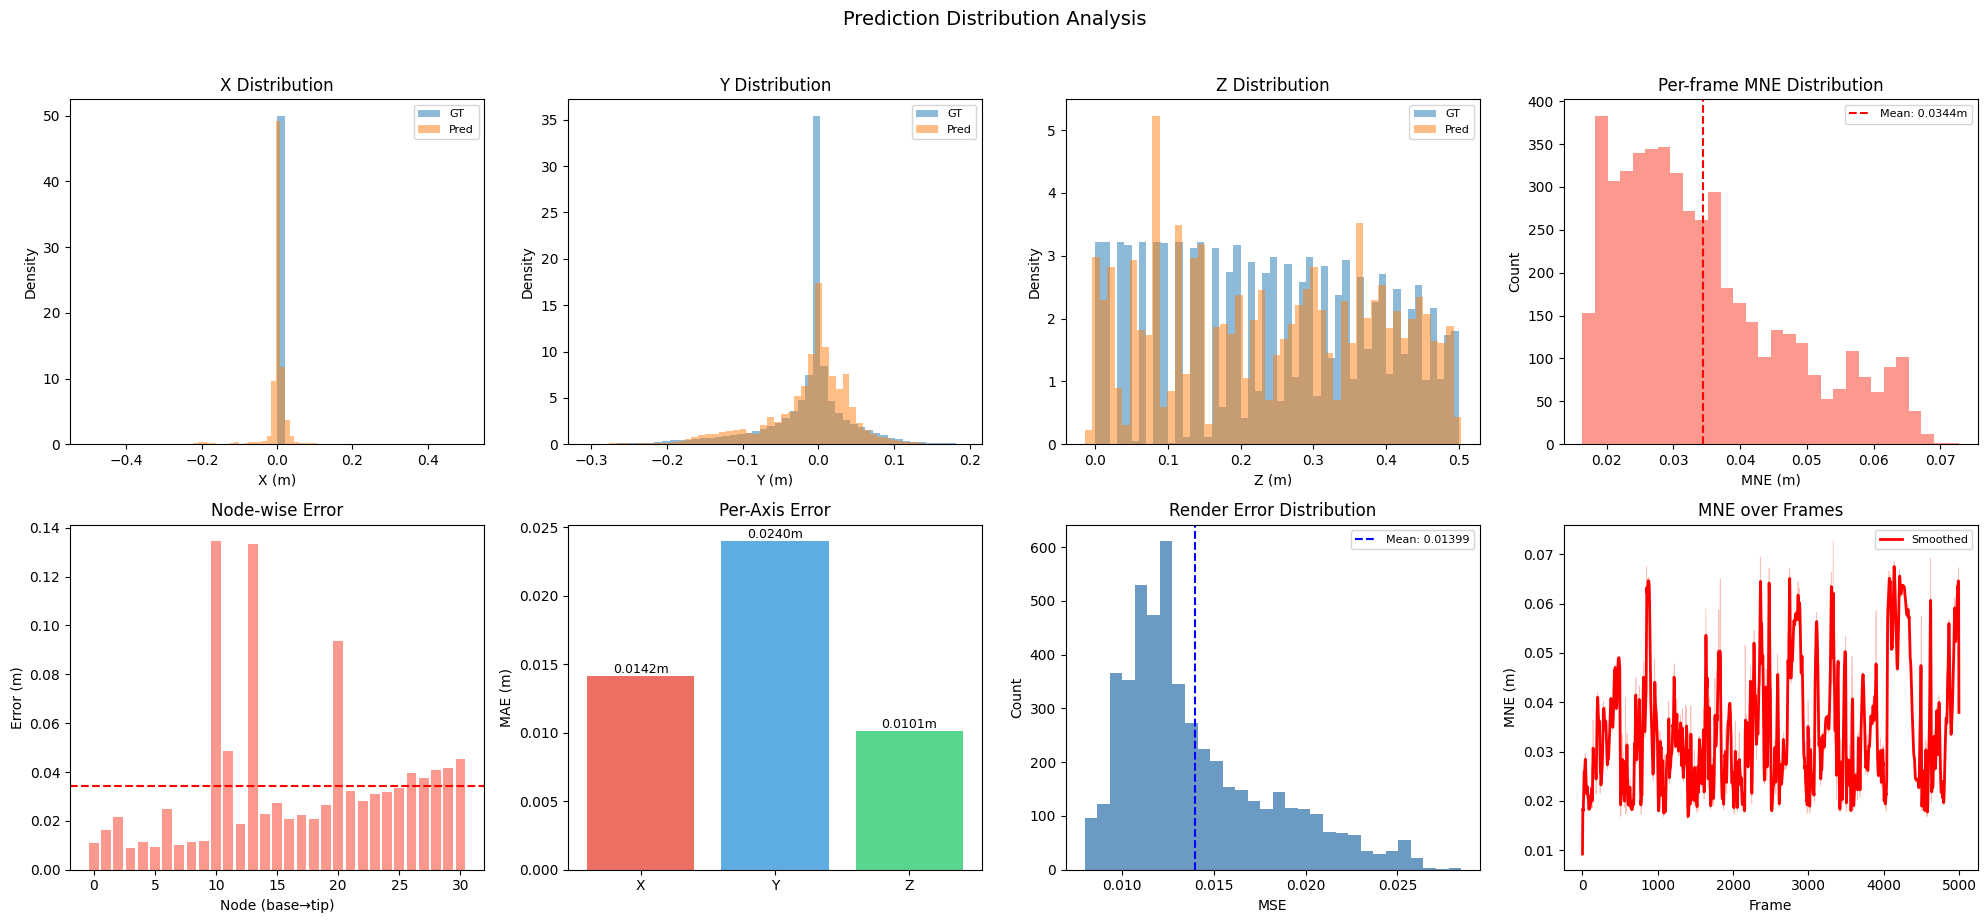

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# Row 1: 3D 骨架坐标分布
for i, (ax, axis_name) in enumerate(zip(axes[0], ['X', 'Y', 'Z'])):
    ax.hist(all_gt_skel[:, :, i].ravel(), bins=50, alpha=0.5, label='GT', density=True)
    ax.hist(all_pred_skel[:, :, i].ravel(), bins=50, alpha=0.5, label='Pred', density=True)
    ax.set_xlabel(f'{axis_name} (m)'); ax.set_ylabel('Density')
    ax.set_title(f'{axis_name} Distribution'); ax.legend(fontsize=8)

# MNE 分布
axes[0, 3].hist(mne_all, bins=30, color='salmon', alpha=0.8)
axes[0, 3].axvline(mne_all.mean(), color='red', linestyle='--', label=f'Mean: {mne_all.mean():.4f}m')
axes[0, 3].set_xlabel('MNE (m)'); axes[0, 3].set_ylabel('Count')
axes[0, 3].set_title('Per-frame MNE Distribution'); axes[0, 3].legend(fontsize=8)

# Row 2: 逐节点误差 + 逐轴误差 + 渲染误差 + 累积误差
# 逐节点误差
axes[1, 0].bar(np.arange(31), node_err, color='salmon', alpha=0.8)
axes[1, 0].axhline(node_err.mean(), color='red', linestyle='--')
axes[1, 0].set_xlabel('Node (base→tip)'); axes[1, 0].set_ylabel('Error (m)')
axes[1, 0].set_title('Node-wise Error')

# 逐轴误差
ax_err = ['X', 'Y', 'Z']
ax_vals = [np.abs(all_pred_skel[:,:,i] - all_gt_skel[:,:,i]).mean() for i in range(3)]
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[1, 1].bar(ax_err, ax_vals, color=colors, alpha=0.8)
for i, v in enumerate(ax_vals):
    axes[1, 1].text(i, v, f'{v:.4f}m', ha='center', va='bottom', fontsize=9)
axes[1, 1].set_ylabel('MAE (m)'); axes[1, 1].set_title('Per-Axis Error')

# 渲染误差分布
render_err = np.mean((all_gt_imgs - all_render_imgs)**2, axis=1)
axes[1, 2].hist(render_err, bins=30, color='steelblue', alpha=0.8)
axes[1, 2].axvline(render_err.mean(), color='blue', linestyle='--', label=f'Mean: {render_err.mean():.5f}')
axes[1, 2].set_xlabel('MSE'); axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Render Error Distribution'); axes[1, 2].legend(fontsize=8)

# 误差随帧变化
axes[1, 3].plot(mne_all, alpha=0.5, linewidth=0.5, color='salmon')
axes[1, 3].plot(np.convolve(mne_all, np.ones(10)/10, mode='same'), 'r-', linewidth=2, label='Smoothed')
axes[1, 3].set_xlabel('Frame'); axes[1, 3].set_ylabel('MNE (m)')
axes[1, 3].set_title('MNE over Frames'); axes[1, 3].legend(fontsize=8)

plt.suptitle('Prediction Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 交互式可视化

3行3列布局：
- **第1行 (2D)**: GT图像 | 渲染图像(带阈值) | 差异叠加
- **第2行 (3D骨架)**: GT骨架 | Pred骨架 | 差异叠加
- **第3行 (3D点云)**: GT点云 | Pred密度点云(带阈值) | 点云差异

密度/可见度阈值会同时影响2D渲染和3D点云：低于阈值的点被置零。

In [7]:
def visualize_frame(frame_idx, density_thresh=0.3, vis_thresh=0.1):
    """交互式可视化单帧：2D图像 + 3D骨架 + 3D点云，阈值同时影响渲染和点云。"""
    fig = plt.figure(figsize=(20, 18))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

    gt_img = all_gt_imgs[frame_idx].reshape(H, W)
    gt_skel = all_gt_skel[frame_idx]     # (31, 3)
    pred_skel = all_pred_skel[frame_idx] # (31, 3)
    b = BOUNDS

    # ====== 带阈值的实时渲染 ======
    aw_t = torch.tensor(all_actions[frame_idx], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        raw = model(pts, aw_t)  # (H*W, n_samp, 2)
        raw_thresh = raw.clone()
        # 对 density 通道应用阈值：raw shape=(H*W, n_samp, 2), channel 1=density
        dens_channel = raw_thresh[..., 1]          # (H*W, n_samp)
        dens_vals = F.softplus(dens_channel)        # (H*W, n_samp)
        dens_channel[dens_vals < density_thresh] = -100.0
        if vis_thresh > 0:
            vis_channel = raw_thresh[..., 0]        # (H*W, n_samp)
            vis_vals = torch.sigmoid(vis_channel)
            vis_mask = vis_vals < vis_thresh
            # 同时要求 density 也被清零
            dens_channel[vis_mask] = -100.0
        render_thresh, _ = OM_rendering(raw_thresh)
    pred_img = render_thresh.cpu().numpy().reshape(H, W).clip(0, 1)

    # ====== Row 1: 2D 图像 ======
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(gt_img, cmap='gray', vmin=0, vmax=1)
    ax1.set_title('GT Image', fontsize=12)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(pred_img, cmap='gray', vmin=0, vmax=1)
    ax2.set_title(f'Rendered (dens>{density_thresh}, vis>{vis_thresh})', fontsize=11)
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[0, 2])
    diff = np.abs(gt_img - pred_img)
    composite = np.zeros((H, W, 3))
    composite[:, :, 0] = gt_img
    composite[:, :, 2] = pred_img
    composite[:, :, 1] = diff * 3
    ax3.imshow(composite.clip(0, 1))
    mse_val = np.mean((gt_img - pred_img)**2)
    ax3.set_title(f'Difference (MSE={mse_val:.4f})', fontsize=12)
    ax3.axis('off')

    # ====== Row 2: 3D 骨架 ======
    ax4 = fig.add_subplot(gs[1, 0], projection='3d')
    ax4.plot(gt_skel[:, 0], gt_skel[:, 1], gt_skel[:, 2],
             'b-o', linewidth=3, markersize=4, label='GT Skeleton')
    ax4.scatter(gt_skel[:, 0], gt_skel[:, 1], gt_skel[:, 2],
                c='blue', s=20, alpha=0.3)
    ax4.set_xlim(b['x']); ax4.set_ylim(b['y']); ax4.set_zlim(b['z'])
    ax4.set_xlabel('X'); ax4.set_ylabel('Y'); ax4.set_zlabel('Z')
    ax4.set_title('GT 3D Skeleton', fontsize=12)
    ax4.set_box_aspect([1, 1, 1])

    ax5 = fig.add_subplot(gs[1, 1], projection='3d')
    ax5.plot(pred_skel[:, 0], pred_skel[:, 1], pred_skel[:, 2],
             'r-o', linewidth=2, markersize=3, label='Pred Skeleton')
    ax5.set_xlim(b['x']); ax5.set_ylim(b['y']); ax5.set_zlim(b['z'])
    ax5.set_xlabel('X'); ax5.set_ylabel('Y'); ax5.set_zlabel('Z')
    ax5.set_title('Pred 3D Skeleton', fontsize=12)
    ax5.set_box_aspect([1, 1, 1])

    ax6 = fig.add_subplot(gs[1, 2], projection='3d')
    ax6.plot(gt_skel[:, 0], gt_skel[:, 1], gt_skel[:, 2],
             'b-o', linewidth=3, markersize=5, alpha=0.6, label='GT')
    ax6.plot(pred_skel[:, 0], pred_skel[:, 1], pred_skel[:, 2],
             'r-o', linewidth=2, markersize=4, alpha=0.8, label='Pred')
    for i in range(0, 31, 3):
        ax6.plot([gt_skel[i, 0], pred_skel[i, 0]],
                 [gt_skel[i, 1], pred_skel[i, 1]],
                 [gt_skel[i, 2], pred_skel[i, 2]],
                 'gray', linewidth=1, alpha=0.5)
    ax6.set_xlim(b['x']); ax6.set_ylim(b['y']); ax6.set_zlim(b['z'])
    ax6.set_xlabel('X'); ax6.set_ylabel('Y'); ax6.set_zlabel('Z')
    mne_val = errors_3d[frame_idx].mean()
    ax6.set_title(f'Skeleton Overlay (MNE={mne_val:.4f}m)', fontsize=12)
    ax6.legend(fontsize=8)
    ax6.set_box_aspect([1, 1, 1])

    # ====== Row 3: 3D 点云 ======
    ax7 = fig.add_subplot(gs[2, 0], projection='3d')
    n_cloud = 80
    gt_cloud_list = []
    for j in range(31):
        center = gt_skel[j]
        pts_local = np.random.randn(n_cloud, 3) * 0.008 + center
        gt_cloud_list.append(pts_local)
    gt_cloud = np.concatenate(gt_cloud_list)
    ax7.scatter(gt_cloud[:, 0], gt_cloud[:, 1], gt_cloud[:, 2],
                c='blue', s=1, alpha=0.1)
    ax7.plot(gt_skel[:, 0], gt_skel[:, 1], gt_skel[:, 2],
             'b-', linewidth=1.5, alpha=0.5)
    ax7.set_xlim(b['x']); ax7.set_ylim(b['y']); ax7.set_zlim(b['z'])
    ax7.set_xlabel('X'); ax7.set_ylabel('Y'); ax7.set_zlabel('Z')
    ax7.set_title('GT Point Cloud', fontsize=12)
    ax7.set_box_aspect([1, 1, 1])

    ax8 = fig.add_subplot(gs[2, 1], projection='3d')
    pred_cloud = None
    if is_ms_scnf and phase >= 1:
        try:
            bounds_tuple = ((-0.3, 0.3), (-0.3, 0.3), (0.0, 0.6))
            cloud = render_density_field(model, aw_t, bounds_tuple,
                                         grid_res=25, threshold=density_thresh,
                                         device=device, batch_size=4096)
            pred_cloud = cloud
            if len(cloud) > 0:
                ax8.scatter(cloud[:, 0], cloud[:, 1], cloud[:, 2],
                            c='orange', s=1, alpha=0.15,
                            label=f'dens>{density_thresh:.2f} ({len(cloud)} pts)')
                ax8.legend(fontsize=8)
        except Exception as e:
            ax8.text2D(0.5, 0.5, f'Density failed: {e}', transform=ax8.transAxes,
                       ha='center', fontsize=9)
    ax8.plot(pred_skel[:, 0], pred_skel[:, 1], pred_skel[:, 2],
             'r-', linewidth=1.5, alpha=0.5)
    ax8.set_xlim(b['x']); ax8.set_ylim(b['y']); ax8.set_zlim(b['z'])
    ax8.set_xlabel('X'); ax8.set_ylabel('Y'); ax8.set_zlabel('Z')
    n_pts = len(pred_cloud) if pred_cloud is not None else 0
    ax8.set_title(f'Pred Point Cloud ({n_pts} pts)', fontsize=12)
    ax8.set_box_aspect([1, 1, 1])

    ax9 = fig.add_subplot(gs[2, 2], projection='3d')
    ax9.scatter(gt_cloud[:, 0], gt_cloud[:, 1], gt_cloud[:, 2],
                c='blue', s=1, alpha=0.08)
    if pred_cloud is not None and len(pred_cloud) > 0:
        ax9.scatter(pred_cloud[:, 0], pred_cloud[:, 1], pred_cloud[:, 2],
                    c='red', s=1, alpha=0.08)
    ax9.plot(gt_skel[:, 0], gt_skel[:, 1], gt_skel[:, 2],
             'b-', linewidth=2, alpha=0.4, label='GT')
    ax9.plot(pred_skel[:, 0], pred_skel[:, 1], pred_skel[:, 2],
             'r-', linewidth=2, alpha=0.6, label='Pred')
    ax9.set_xlim(b['x']); ax9.set_ylim(b['y']); ax9.set_zlim(b['z'])
    ax9.set_xlabel('X'); ax9.set_ylabel('Y'); ax9.set_zlabel('Z')
    ax9.set_title('Point Cloud Overlay', fontsize=12)
    ax9.legend(fontsize=8)
    ax9.set_box_aspect([1, 1, 1])

    fig.suptitle(f'Frame {frame_idx}/{n_samples-1}', fontsize=14, y=1.01)
    plt.show()


frame_slider = IntSlider(min=0, max=n_samples-1, step=1, value=0, description='Frame')
density_slider = FloatSlider(min=0.0, max=2.0, step=0.05, value=0.3, description='Density Thr')
vis_slider = FloatSlider(min=0.0, max=1.0, step=0.05, value=0.1, description='Vis Thr')

interact(visualize_frame, frame_idx=frame_slider,
         density_thresh=density_slider, vis_thresh=vis_slider)

interactive(children=(IntSlider(value=0, description='Frame', max=4999), FloatSlider(value=0.3, description='D…

<function __main__.visualize_frame(frame_idx, density_thresh=0.3, vis_thresh=0.1)>

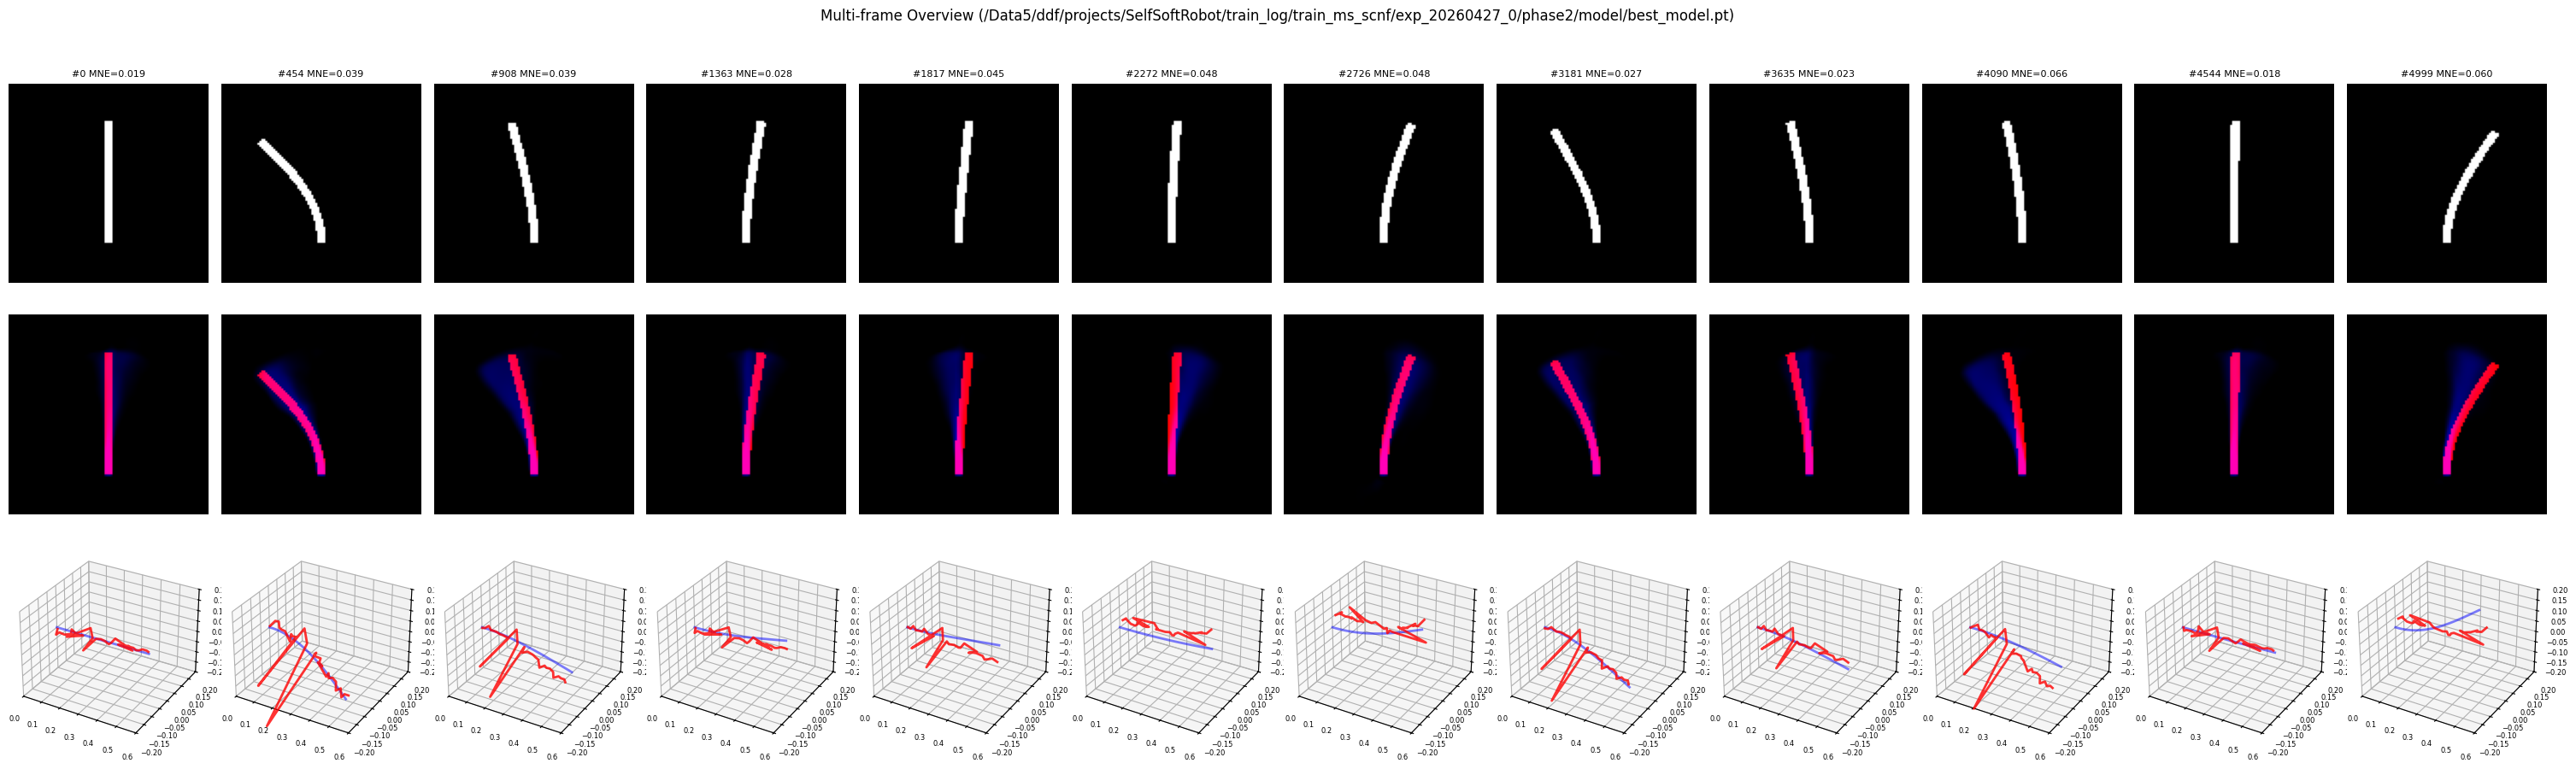

In [8]:
n_show = min(12, n_samples)
indices = np.linspace(0, n_samples-1, n_show, dtype=int)

fig, axes = plt.subplots(3, n_show, figsize=(2.5*n_show, 9))

for col, idx in enumerate(indices):
    gt_img = all_gt_imgs[idx].reshape(H, W)
    pred_img = all_render_imgs[idx].reshape(H, W).clip(0, 1)
    gt_s = all_gt_skel[idx]
    pred_s = all_pred_skel[idx]

    # Row 1: 2D GT
    axes[0, col].imshow(gt_img, cmap='gray')
    axes[0, col].set_title(f'#{idx} MNE={mne_all[idx]:.3f}', fontsize=8)
    axes[0, col].axis('off')

    # Row 2: 2D Rendered
    composite = np.zeros((H, W, 3))
    composite[:,:,0] = gt_img
    composite[:,:,2] = pred_img
    axes[1, col].imshow(composite.clip(0, 1))
    axes[1, col].axis('off')

    # Row 3: 3D Overlay
    ax3d = fig.add_subplot(3, n_show, 2*n_show + col + 1, projection='3d')
    ax3d.plot(gt_s[:, 2], gt_s[:, 0], gt_s[:, 1], 'b-', linewidth=2, alpha=0.5)
    ax3d.plot(pred_s[:, 2], pred_s[:, 0], pred_s[:, 1], 'r-', linewidth=2, alpha=0.8)
    ax3d.set_xlim(0, 0.6); ax3d.set_ylim(-0.2, 0.2); ax3d.set_zlim(-0.2, 0.2)
    ax3d.tick_params(labelsize=6)

# 删除空 subplot（Row 3 使用 add_subplot）
for col in range(n_show):
    axes[2, col].remove()

axes[0, 0].set_ylabel('GT Image', fontsize=10)
axes[1, 0].set_ylabel('Diff (R=GT,B=Pred)', fontsize=10)
plt.suptitle(f'Multi-frame Overview ({checkpoint_path})', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. 密度场切片分析

在固定Z高度切片查看密度场分布，理解模型学到的3D形状。

In [9]:
@interact(frame_idx=IntSlider(min=0, max=n_samples-1, value=0, description='Frame'),
          z_level=FloatSlider(min=0.0, max=0.5, step=0.02, value=0.25, description='Z (m)'),
          grid_res=IntSlider(min=20, max=60, step=5, value=30, description='Resolution'))
def density_slice(frame_idx, z_level, grid_res):
    if not is_ms_scnf:
        print('Density slice only available for MS-SCNF models')
        return

    aw_t = torch.tensor(all_actions[frame_idx]).unsqueeze(0).to(device)

    xs = np.linspace(-0.2, 0.2, grid_res)
    ys = np.linspace(-0.2, 0.2, grid_res)
    gx, gy = np.meshgrid(xs, ys)
    pts = np.stack([gx.ravel(), gy.ravel(), np.full(grid_res**2, z_level)], axis=-1)
    pts_t = torch.tensor(pts, dtype=torch.float32, device=device).unsqueeze(1)  # (N, 1, 3)

    with torch.no_grad():
        output = model(pts_t, aw_t)
        vis = output[:, 0, 0].cpu().numpy()
        dens = F.softplus(output[:, 0, 1]).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    vis_map = vis.reshape(grid_res, grid_res)
    dens_map = dens.reshape(grid_res, grid_res)

    im0 = axes[0].imshow(vis_map, extent=[-0.2, 0.2, -0.2, 0.2], origin='lower', cmap='viridis')
    axes[0].set_title(f'Visibility at Z={z_level:.2f}m')
    axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(dens_map, extent=[-0.2, 0.2, -0.2, 0.2], origin='lower', cmap='hot')
    axes[1].set_title(f'Density at Z={z_level:.2f}m')
    axes[1].set_xlabel('X (m)'); axes[1].set_ylabel('Y (m)')
    plt.colorbar(im1, ax=axes[1])

    # 标记 GT 骨架在该 Z 高度的位置
    gt_s = all_gt_skel[frame_idx]
    pred_s = all_pred_skel[frame_idx]
    for skel, color, label in [(gt_s, 'cyan', 'GT'), (pred_s, 'red', 'Pred')]:
        for ax in axes:
            ax.scatter(skel[:, 0], skel[:, 1], c=color, s=10, alpha=0.5, label=label)
            break  # only on first axis
    axes[0].legend(fontsize=8)

    plt.suptitle(f'Frame {frame_idx}', fontsize=12)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='Frame', max=4999), FloatSlider(value=0.25, description='…

## 7. 动作-形态对应分析

查看驱动参数与骨架变形的对应关系，验证模型是否学到了正确的物理响应。

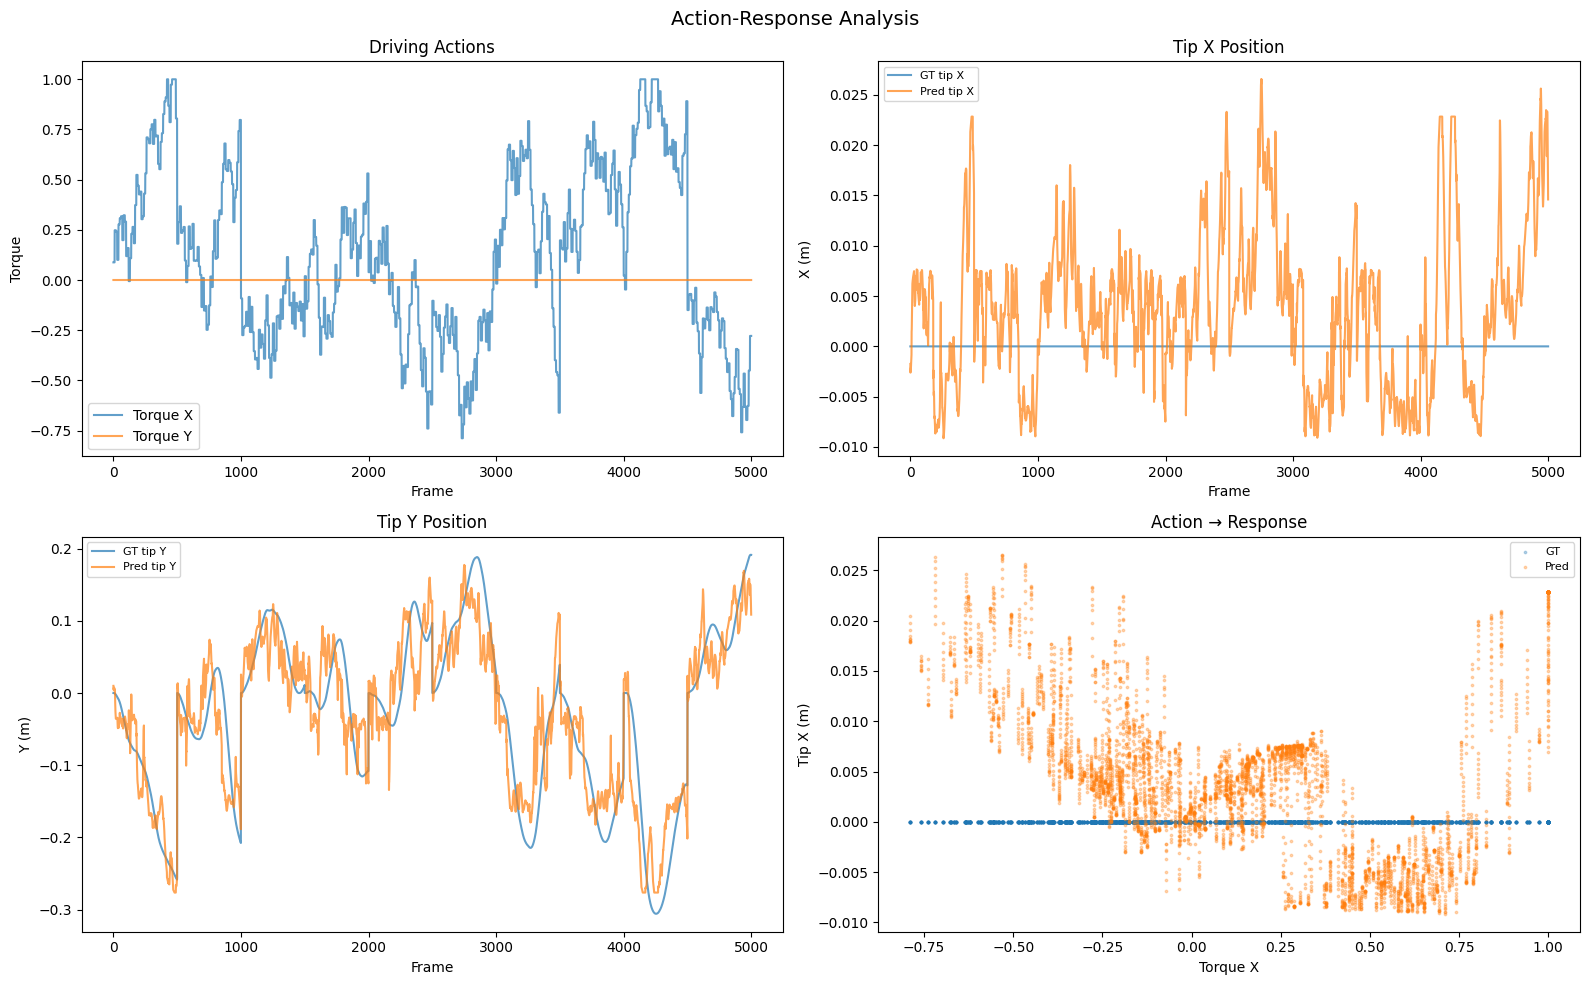

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 驱动参数时序
act = all_actions[:, -1, :]  # 取每个窗口最后一个动作 (N, 2)
axes[0, 0].plot(act[:, 0], label='Torque X', alpha=0.7)
axes[0, 0].plot(act[:, 1], label='Torque Y', alpha=0.7)
axes[0, 0].set_xlabel('Frame'); axes[0, 0].set_ylabel('Torque')
axes[0, 0].set_title('Driving Actions'); axes[0, 0].legend()

# 骨架端点位移 vs 驱动
gt_tip_x = all_gt_skel[:, -1, 0]
gt_tip_y = all_gt_skel[:, -1, 1]
pred_tip_x = all_pred_skel[:, -1, 0]
pred_tip_y = all_pred_skel[:, -1, 1]

axes[0, 1].plot(gt_tip_x, label='GT tip X', alpha=0.7)
axes[0, 1].plot(pred_tip_x, label='Pred tip X', alpha=0.7)
axes[0, 1].set_xlabel('Frame'); axes[0, 1].set_ylabel('X (m)')
axes[0, 1].set_title('Tip X Position'); axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(gt_tip_y, label='GT tip Y', alpha=0.7)
axes[1, 0].plot(pred_tip_y, label='Pred tip Y', alpha=0.7)
axes[1, 0].set_xlabel('Frame'); axes[1, 0].set_ylabel('Y (m)')
axes[1, 0].set_title('Tip Y Position'); axes[1, 0].legend(fontsize=8)

# 动作 vs 端点位移散点图
axes[1, 1].scatter(act[:, 0], gt_tip_x, s=3, alpha=0.3, label='GT')
axes[1, 1].scatter(act[:, 0], pred_tip_x, s=3, alpha=0.3, label='Pred')
axes[1, 1].set_xlabel('Torque X'); axes[1, 1].set_ylabel('Tip X (m)')
axes[1, 1].set_title('Action → Response'); axes[1, 1].legend(fontsize=8)

plt.suptitle('Action-Response Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 8. 逐帧骨架动画（可选保存为 GIF）

In [11]:
from src.utils.skeleton_viz import animate_skeleton_sequence

# 选择帧范围
start, end = 0, min(300, n_samples)
save_gif_path = os.path.join('output', f'validation_{model_type}_phase{phase}.gif')
os.makedirs('output', exist_ok=True)

print(f'生成动画: frames {start}-{end}...')
ani = animate_skeleton_sequence(
    pred_seq=all_pred_skel[start:end],
    gt_seq=all_gt_skel[start:end],
    actions=all_actions[start:end, -1, :],
    save_path=save_gif_path,
    fps=10,
)
print(f'保存至: {save_gif_path}')

生成动画: frames 0-300...
Animation saved to output/validation_ms_scnf_phase2.gif
保存至: output/validation_ms_scnf_phase2.gif


## 9. 定量指标汇总

In [12]:
print('='*60)
print('  模型验证报告')
print('='*60)
print(f'模型: {checkpoint_path}')
print(f'数据: {data_dir} ({n_samples} 样本)')
print(f'类型: {model_type} (Phase {phase})')
print()

# 3D 骨架指标
err_x = np.abs(all_pred_skel[:,:,0] - all_gt_skel[:,:,0]).mean()
err_y = np.abs(all_pred_skel[:,:,1] - all_gt_skel[:,:,1]).mean()
err_z = np.abs(all_pred_skel[:,:,2] - all_gt_skel[:,:,2]).mean()
total_3d = np.sqrt(err_x**2 + err_y**2 + err_z**2)

print(f'--- 3D 骨架精度 ---')
print(f'MNE:       {mne_all.mean():.6f} m')
print(f'Tip Error: {errors_3d[:,-1].mean():.6f} m')
print(f'X err:     {err_x:.6f} m  ({err_x/total_3d*100:.1f}%)')
print(f'Y err:     {err_y:.6f} m  ({err_y/total_3d*100:.1f}%)')
print(f'Z err:     {err_z:.6f} m  ({err_z/total_3d*100:.1f}%)')
print()

# 渲染质量
mse = np.mean((all_gt_imgs - all_render_imgs)**2)
psnr = 10 * np.log10(1.0 / max(mse, 1e-10))
print(f'--- 渲染质量 ---')
print(f'MSE:  {mse:.6f}')
print(f'PSNR: {psnr:.2f} dB')
print()

# print_metrics 详细
print('--- 详细指标 (mean sample) ---')
mean_idx = np.argmin(np.abs(mne_all - mne_all.mean()))
print_metrics(all_pred_skel[mean_idx], all_gt_skel[mean_idx], label='Mean-frame')

worst_idx = np.argmax(mne_all)
print_metrics(all_pred_skel[worst_idx], all_gt_skel[worst_idx], label='Worst-frame')

  模型验证报告
模型: /Data5/ddf/projects/SelfSoftRobot/train_log/train_ms_scnf/exp_20260427_0/phase2/model/best_model.pt
数据: /Data5/ddf/projects/SelfSoftRobot/data/seq_rz_3d (5000 样本)
类型: ms_scnf (Phase 2)

--- 3D 骨架精度 ---
MNE:       0.034408 m
Tip Error: 0.045414 m
X err:     0.014163 m  (47.8%)
Y err:     0.023963 m  (80.9%)
Z err:     0.010127 m  (34.2%)

--- 渲染质量 ---
MSE:  0.013992
PSNR: 18.54 dB

--- 详细指标 (mean sample) ---
[Mean-frame] MNE=0.034410m  EPE=0.066330m  Smooth=0.048963  CD=0.001285
[Worst-frame] MNE=0.072781m  EPE=0.177263m  Smooth=0.047945  CD=0.006139


{'mne': 0.07278052717447281,
 'epe': 0.17726343870162964,
 'smoothness': 0.04794542118906975,
 'cd': 0.006138500291854143}

正在初始化环境稳定性...
Running 30 live simulation steps...


2026-04-29 21:03:52.148 (   1.640s) [    7FCE4ACCB280]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


  Step   0/30: MNE=2.038634m
  Step   5/30: MNE=1.417648m
  Step  10/30: MNE=2.074181m
  Step  15/30: MNE=3.968483m
  Step  20/30: MNE=1.292434m
  Step  25/30: MNE=1.864251m

Average Live MNE: 2.033614m


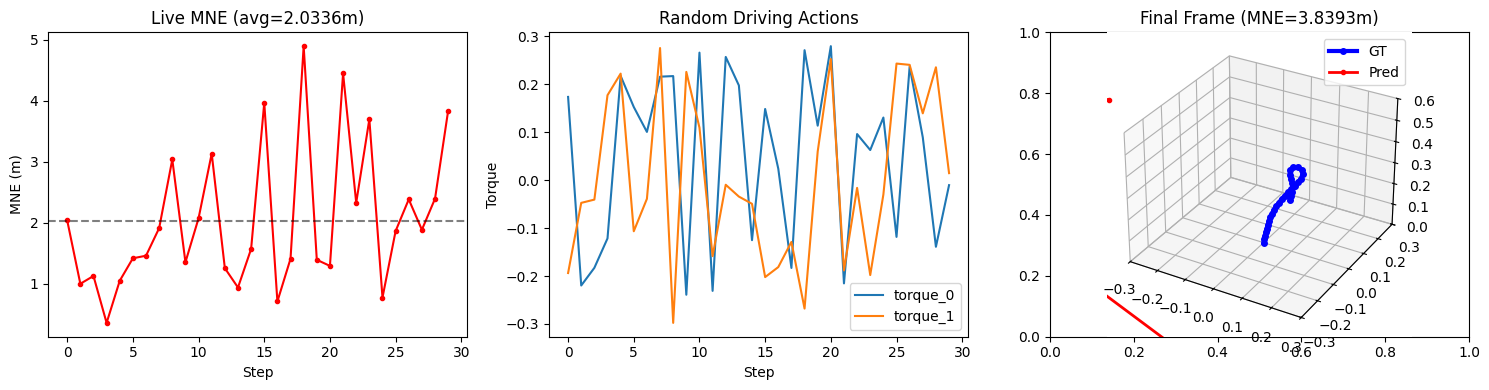

In [13]:
from elastica_env import ContinuousSoftArmEnv

env = ContinuousSoftArmEnv(dt=1e-4)
norm_factor = info['norm_factor']
window_size = info['window_size']
action_dim = info['action_dim']

history = np.zeros((1, window_size, action_dim))

N_LIVE_STEPS = 30
SIM_STEPS = 500

live_pred, live_gt, live_actions, live_mne = [], [], [], []

print(f'Running {N_LIVE_STEPS} live simulation steps...')
for step in range(N_LIVE_STEPS):
    action = np.random.uniform(-0.3, 0.3, size=action_dim)
    env.set_action(action)
    for _ in range(SIM_STEPS):
        env.step(steps=1)

    _, _, positions, _ = env.get_observation_3d()
    gt = positions.T  # (31, 3)

    act_norm = action / norm_factor
    history = np.roll(history, -1, axis=1)
    history[0, -1] = act_norm
    aw_tensor = torch.from_numpy(history).float().to(device)

    with torch.no_grad():
        pred = model.predict_skeleton(aw_tensor)['fine'][0].cpu().numpy()

    mne = np.linalg.norm(pred - gt, axis=1).mean()
    live_pred.append(pred)
    live_gt.append(gt)
    live_actions.append(action)
    live_mne.append(mne)

    if step % 5 == 0:
        print(f'  Step {step:3d}/{N_LIVE_STEPS}: MNE={mne:.6f}m')

live_pred = np.stack(live_pred)
live_gt = np.stack(live_gt)
live_actions = np.stack(live_actions)
print(f'\nAverage Live MNE: {np.mean(live_mne):.6f}m')

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(live_mne, 'r-o', markersize=3)
axes[0].axhline(np.mean(live_mne), color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MNE (m)')
axes[0].set_title(f'Live MNE (avg={np.mean(live_mne):.4f}m)')

for d in range(action_dim):
    axes[1].plot(live_actions[:, d], label=f'torque_{d}')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Torque')
axes[1].legend(); axes[1].set_title('Random Driving Actions')

ax3d = fig.add_subplot(133, projection='3d')
ax3d.plot(live_gt[-1][:, 0], live_gt[-1][:, 1], live_gt[-1][:, 2],
          'b-o', linewidth=3, markersize=4, label='GT')
ax3d.plot(live_pred[-1][:, 0], live_pred[-1][:, 1], live_pred[-1][:, 2],
          'r-o', linewidth=2, markersize=3, label='Pred')
ax3d.set_xlim(-0.3, 0.3); ax3d.set_ylim(-0.3, 0.3); ax3d.set_zlim(0, 0.6)
ax3d.set_title(f'Final Frame (MNE={live_mne[-1]:.4f}m)'); ax3d.legend()

plt.tight_layout()
plt.show()

## 10. 多尺度骨架分析

对比 MS-SCNF 的 coarse / medium / fine 三个尺度预测。

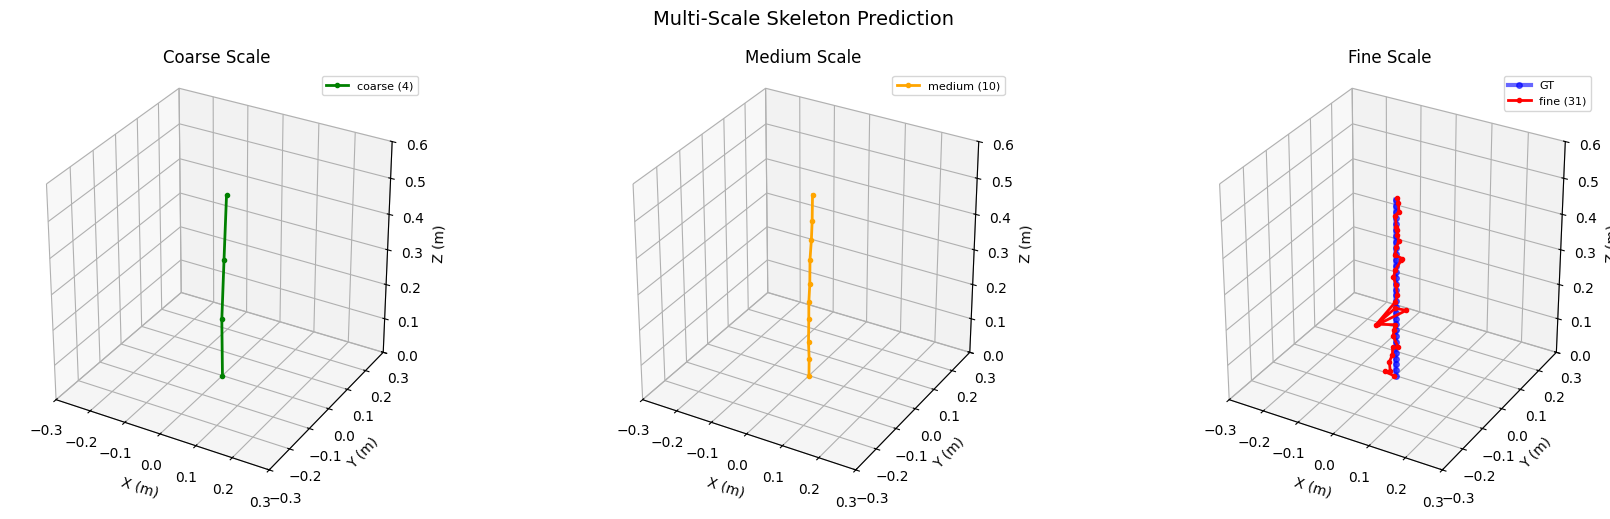

Frame 0: coarse=(4, 3), medium=(10, 3), fine=(31, 3)


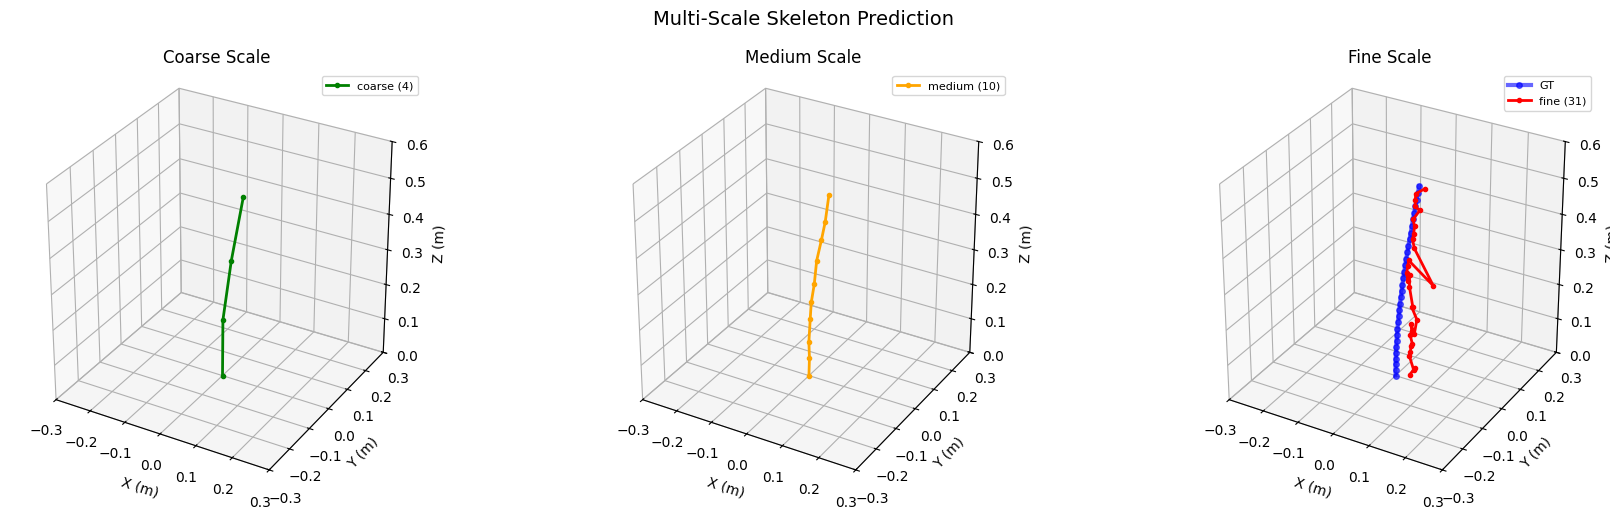

Frame 1250: coarse=(4, 3), medium=(10, 3), fine=(31, 3)


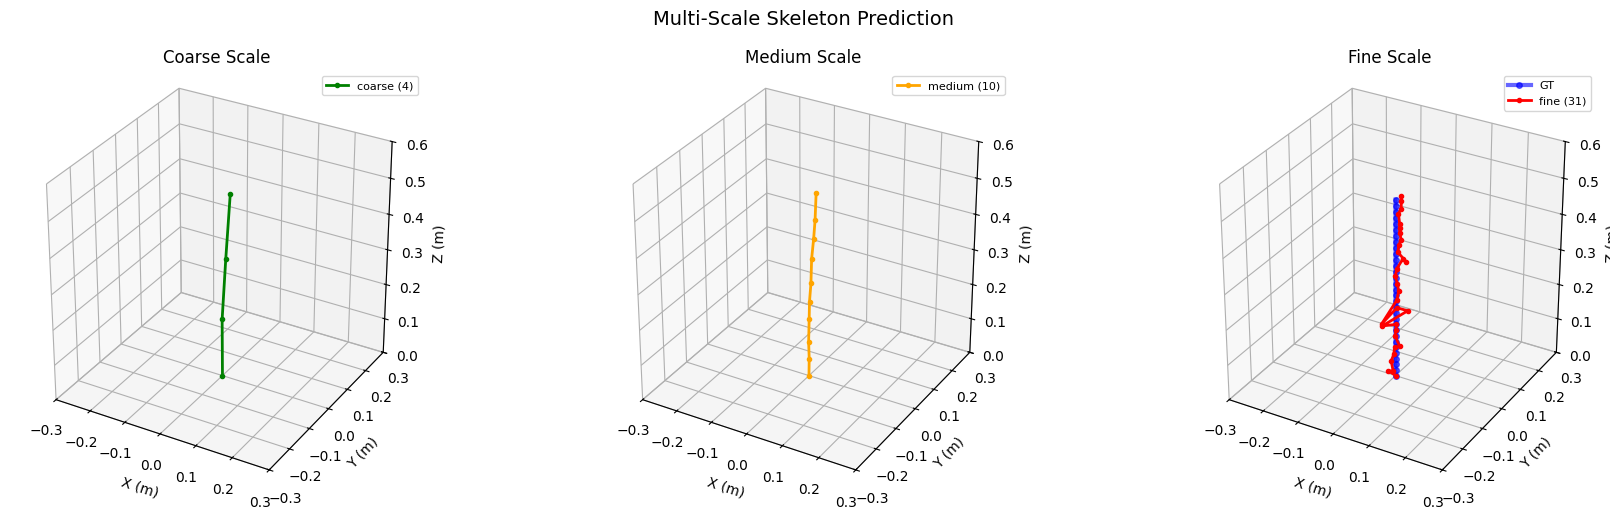

Frame 2500: coarse=(4, 3), medium=(10, 3), fine=(31, 3)


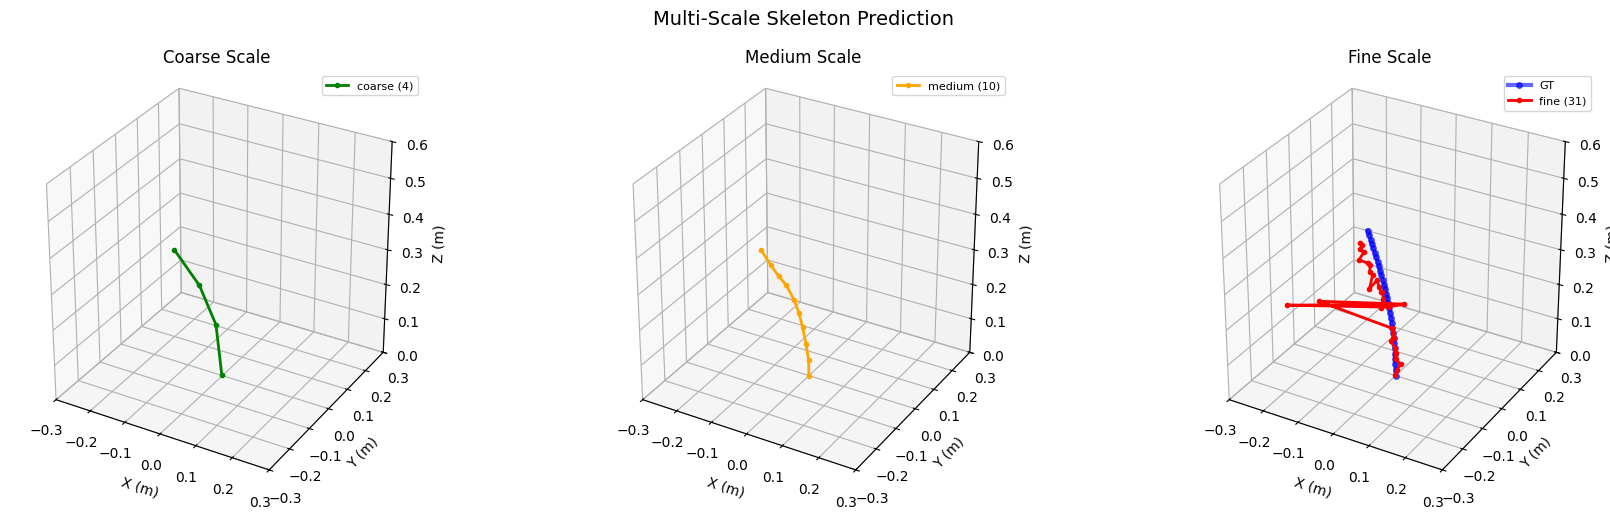

Frame 3750: coarse=(4, 3), medium=(10, 3), fine=(31, 3)


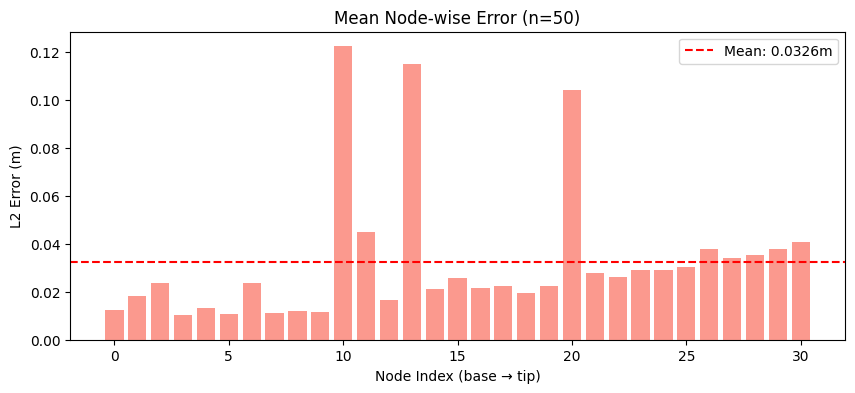

Tip error: 0.040895 m


In [14]:
from src.utils.skeleton_viz import plot_multi_scale, plot_error_along_arm

if is_ms_scnf:
    # 取几个代表性帧做多尺度分析
    for idx in [0, n_samples//4, n_samples//2, 3*n_samples//4]:
        sample = ds[idx]
        aw = sample[0].unsqueeze(0).to(device)
        gt = sample[-1].numpy().T  # (31, 3)

        with torch.no_grad():
            pred_dict = model.predict_skeleton(aw)

        np_pred = {k: v[0].cpu().numpy() for k, v in pred_dict.items()}
        plot_multi_scale(np_pred, gt=gt, show=True)
        print(f'Frame {idx}: coarse={np_pred["coarse"].shape}, medium={np_pred["medium"].shape}, fine={np_pred["fine"].shape}')

    # 统计逐节点误差（多样本）
    N_STAT = 50
    stat_errors = []
    loader_stat = DataLoader(ds, batch_size=8, shuffle=True)
    count = 0
    with torch.no_grad():
        for batch in loader_stat:
            if count >= N_STAT: break
            aw = batch[0].to(device)
            gt = batch[-1].numpy()
            pred = model.predict_skeleton(aw)['fine'].cpu().numpy()
            for b in range(pred.shape[0]):
                if count >= N_STAT: break
                stat_errors.append(np.linalg.norm(pred[b] - gt[b].T, axis=1))
                count += 1

    stat_errors = np.array(stat_errors)
    plot_error_along_arm(stat_errors.mean(axis=0), title=f'Mean Node-wise Error (n={N_STAT})')
    print(f'Tip error: {stat_errors[:, -1].mean():.6f} m')
else:
    print('多尺度分析仅适用于 MS-SCNF 模型')